## CNN Project: Transfer Learning vs Fine-Tuning with ResNet-18 on Intel Image Classification Dataset

This notebook demonstrates two common techniques in deep learning for image classification: **Transfer Learning** and **Fine-Tuning**. Both approaches leverage a pre-trained ResNet-18 model, which has learned powerful features from a large dataset like ImageNet. The goal is to classify images from the Intel Image Classification Dataset into six categories: buildings, forest, glacier, mountain, sea, and street.

### Workflow Overview:
1.  **Import Libraries**: Essential libraries for data manipulation, deep learning (PyTorch), and visualization.
2.  **Data Preprocessing**: Define transformations for training and testing datasets.
3.  **Load Dataset**: Load and split the Intel Image Classification dataset.
4.  **Show Sample Images**: Visualize examples from the dataset.
5.  **Transfer Learning Model**: Load ResNet-18, freeze most layers, and train only the final classification layer.
6.  **Fine-Tuning Model**: Load ResNet-18, unfreeze later layers (e.g., `layer3`, `layer4`) in addition to the classification layer, and train with a lower learning rate.
7.  **Training and Evaluation**: Implement a generic training function and evaluate both models.
8.  **Comparison and Analysis**: Compare the performance of Transfer Learning and Fine-Tuning.
9.  **Save Models**: Save the trained models for future use.

In [ ]:
# ============================================================
# CNN PROJECT
# Transfer Learning vs Fine-Tuning using ResNet-18
# Intel Image Classification Dataset
# ============================================================

# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using Device: cuda


### CELL 1: Import Libraries

This cell imports all the necessary Python libraries for the project. Key libraries include:

-   `os`, `copy`, `time`, `numpy`, `matplotlib.pyplot`, `seaborn`: Standard utilities for system interaction, data manipulation, timing, and plotting.
-   `sklearn.metrics`: For evaluating model performance (confusion matrix, classification report, accuracy).
-   `torch`, `torch.nn`, `torch.optim`: Core PyTorch modules for building and training neural networks.
-   `torchvision.datasets`, `torchvision.transforms`, `torchvision.models`: PyTorch's vision library for image datasets, data augmentation, and pre-trained models.
-   `torch.utils.data.DataLoader`: For efficient loading of data in batches.

**Special Aspects:**
-   `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")`: This line dynamically selects the computing device. If a CUDA-enabled GPU is available, it will use the GPU; otherwise, it defaults to the CPU. This is crucial for accelerating deep learning training.
-   `torch.manual_seed(42)` and `np.random.seed(42)`: These lines set random seeds for PyTorch and NumPy, respectively. Setting seeds ensures that the results are reproducible across different runs, which is important for debugging and comparing experiments.

In [ ]:
# ============================================================
# CELL 2 — DATA PREPROCESSING
# ============================================================

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### CELL 2: Data Preprocessing

This cell defines the image transformations applied to the training and testing datasets. These transformations are crucial for preparing the images for input into a neural network and for data augmentation.

-   `train_transforms`: Applied to the training data. It includes data augmentation techniques to introduce variability, helping the model generalize better and reduce overfitting.
    -   `RandomResizedCrop(224, scale=(0.8, 1.0))`: Crops the image to a random size and aspect ratio, then resizes it to 224x224 pixels. `scale` controls the range of areas to crop.
    -   `RandomHorizontalFlip()`: Randomly flips the image horizontally.
    -   `RandomRotation(15)`: Randomly rotates the image by up to 15 degrees.
    -   `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)`: Randomly changes the brightness, contrast, and saturation of the images.
    -   `ToTensor()`: Converts the PIL Image or NumPy array to a PyTorch `FloatTensor` and scales the pixel intensity values to the range [0.0, 1.0].
    -   `Normalize(mean, std)`: Normalizes the tensor image with mean and standard deviation for each channel. These specific values `[0.485, 0.456, 0.406]` and `[0.229, 0.224, 0.225]` are common for images pre-trained on ImageNet, matching the expectations of models like ResNet.

-   `test_transforms`: Applied to the testing (and validation) data. It typically includes only resizing and normalization to ensure consistent input size and scale without introducing artificial variations that might not be present in real-world data.
    -   `Resize((224, 224))`: Resizes the image to a fixed 224x224 pixels.
    -   `ToTensor()` and `Normalize`: Same as for training data.

In [ ]:
!unzip Intel_Image_Classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

### CELL 3: Unzip Dataset

This cell executes a shell command `!unzip Intel_Image_Classification.zip` to extract the contents of the `Intel_Image_Classification.zip` file. This is a common step when working with compressed datasets in environments like Google Colab.

**Special Aspect:**
-   `!`: The exclamation mark prefix indicates that the command is a shell command, not Python code. This allows direct execution of terminal commands within the notebook environment.

In [ ]:
# ============================================================
# CELL 3 — LOAD DATASET
# ============================================================

# CHANGE PATHS TO YOUR DATASET LOCATION

train_dir = "seg_train/seg_train"
test_dir = "seg_test/seg_test"

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

class_names = train_dataset.classes

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transforms
)

from torch.utils.data import random_split

val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of Classes: 6


### CELL 4: Load Dataset

This cell loads the image dataset, organizes it, and prepares it for training, validation, and testing.

-   `train_dir` and `test_dir`: Define the paths to the training and testing image directories after unzipping.
-   `datasets.ImageFolder`: A convenient PyTorch dataset class that expects image data organized in subfolders, where each subfolder represents a class.
    -   It automatically infers class names from subfolder names (`class_names`).
    -   It applies the `train_transforms` to the training dataset and `test_transforms` to the test dataset.
-   `random_split`: Divides the `train_dataset` into a training set and a validation set. The `val_size` is set to 20% of the original training dataset.
-   `DataLoader`: Creates iterable data loaders for training, validation, and testing.
    -   `batch_size=64`: Images are processed in batches of 64.
    -   `shuffle=True` (for train_loader): Shuffles the training data each epoch to prevent the model from learning the order of samples.
    -   `shuffle=False` (for val_loader, test_loader): No need to shuffle validation/test data.
    -   `num_workers=2`: Uses 2 subprocesses for data loading, which can speed up the process by loading data in the background.
    -   `pin_memory=True`: Optimizes data transfer to GPU by pre-fetching data into pinned (non-pageable) memory.

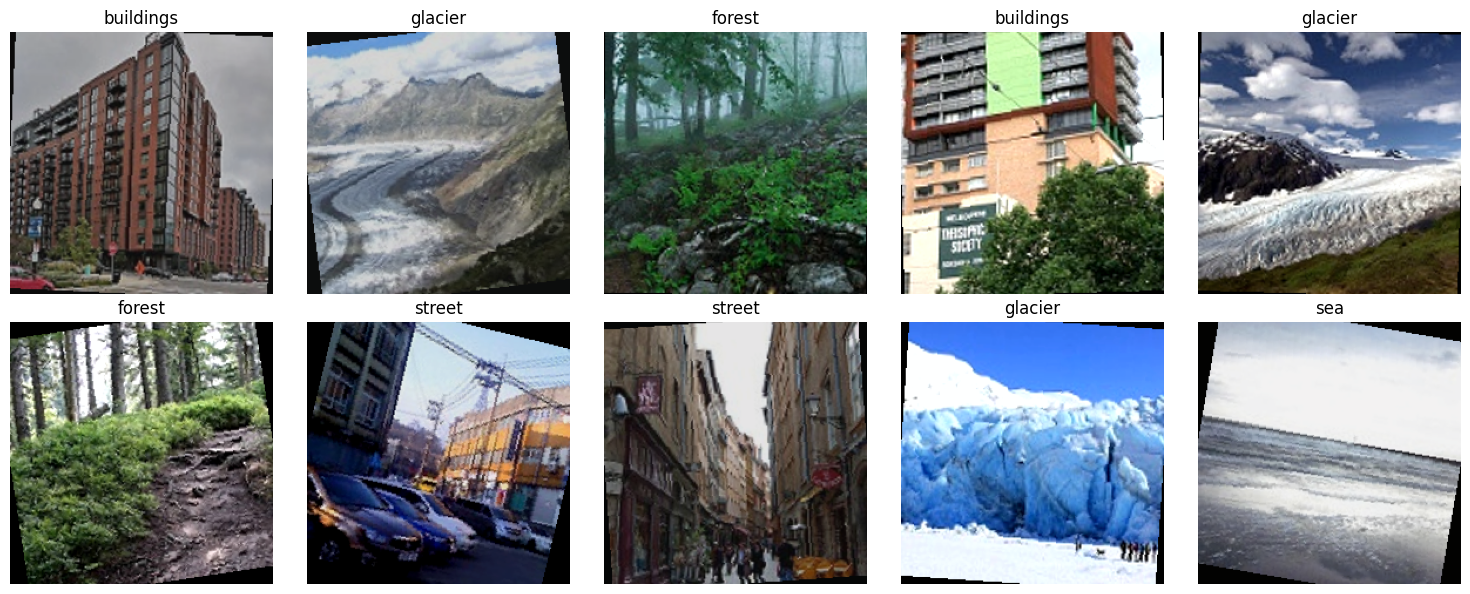

In [ ]:
# ============================================================
# CELL 4 — SHOW SAMPLE IMAGES
# ============================================================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

### CELL 5: Show Sample Images

This cell visualizes a batch of images from the training data loader, along with their corresponding class labels. This helps to verify that the data loading and preprocessing steps are working correctly.

**Special Aspects:**
-   `images, labels = next(iter(train_loader))`: Retrieves the first batch of images and labels from the training data loader.
-   `img = images[i].permute(1, 2, 0).numpy()`: Images in PyTorch are typically in (Channel, Height, Width) format. For displaying with `matplotlib.pyplot.imshow`, they need to be converted to (Height, Width, Channel) format and then to a NumPy array.
-   **Denormalization**: The images were normalized during preprocessing (`transforms.Normalize`). To display them correctly (i.e., in their original visual range), they need to be denormalized using the inverse operation: `img = std * img + mean`. This reverses the normalization process, bringing pixel values back to a visible range (0-1 or 0-255).
-   `np.clip(img, 0, 1)`: Ensures that all pixel values are within the valid range of [0, 1] after denormalization, preventing potential display issues.
-   `ax.set_title(class_names[labels[i]])`: Sets the title of each subplot to the predicted class name using the `class_names` list derived from the dataset.

In [ ]:
# ============================================================
# CELL 5 — LOAD PRETRAINED RESNET18
# TRANSFER LEARNING
# ============================================================

model_tl = models.resnet18(weights='DEFAULT')

# Freeze all layers
for param in model_tl.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model_tl.fc.in_features

model_tl.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, len(class_names))
)

model_tl = model_tl.to(device)

print(model_tl)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### CELL 6: Load Pretrained ResNet-18 for Transfer Learning

This cell initializes a pre-trained ResNet-18 model for the **Transfer Learning** approach. In transfer learning, a model pre-trained on a large general-purpose dataset (like ImageNet) is used as a feature extractor, and only its final classification layer is trained on the new dataset.

**Special Aspects:**
-   `model_tl = models.resnet18(weights='DEFAULT')`: Loads the ResNet-18 architecture with pre-trained weights from ImageNet. `weights='DEFAULT'` specifies that the latest available pre-trained weights should be used.
-   **Freezing Layers**: `for param in model_tl.parameters(): param.requires_grad = False` is a crucial step. It iterates through all parameters of the ResNet-18 model and sets `requires_grad` to `False`. This prevents the weights of the pre-trained convolutional layers from being updated during training, effectively using them as fixed feature extractors.
-   **Replacing the Final Layer**: The original ResNet-18 was trained on 1000 ImageNet classes. We need to adapt it for our 6 classes.
    -   `num_features = model_tl.fc.in_features`: Gets the number of input features to the original fully connected (classifier) layer.
    -   `model_tl.fc = nn.Sequential(...)`: Replaces the original `fc` layer with a new `nn.Sequential` block. This new block typically includes:
        -   `nn.Dropout(0.3)`: A dropout layer is added for regularization, randomly setting a fraction of input units to zero at each update during training to prevent overfitting.
        -   `nn.Linear(num_features, len(class_names))`: A new linear (fully connected) layer that takes `num_features` as input and outputs `len(class_names)` (which is 6 for our dataset) logits, corresponding to the new classification task. This new layer's parameters are initialized randomly and *will be trained* because `requires_grad` is `True` by default for newly created layers.
-   `model_tl = model_tl.to(device)`: Moves the entire model to the selected computing device (GPU or CPU).

In [ ]:
# ============================================================
# CELL 6 — LOSS AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer_tl = optim.Adam(
    model_tl.fc.parameters(),
    lr=0.001
)

scheduler_tl = optim.lr_scheduler.CosineAnnealingLR(optimizer_tl, T_max=10)

### CELL 7: Loss and Optimizer for Transfer Learning

This cell defines the criterion (loss function), optimizer, and learning rate scheduler specifically for the Transfer Learning model (`model_tl`).

**Special Aspects:**
-   `criterion = nn.CrossEntropyLoss()`: This is the standard loss function used for multi-class classification problems in PyTorch. It combines `nn.LogSoftmax` and `nn.NLLLoss` in a single class.
-   `optimizer_tl = optim.Adam(model_tl.fc.parameters(), lr=0.001)`: An Adam optimizer is chosen. Critically, it's configured to optimize **only the parameters of the newly added `fc` layer** (`model_tl.fc.parameters()`). The learning rate (`lr`) is set to 0.001.
-   `scheduler_tl = optim.lr_scheduler.CosineAnnealingLR(optimizer_tl, T_max=10)`: A learning rate scheduler is used to adjust the learning rate during training. `CosineAnnealingLR` varies the learning rate following a cosine curve between an initial learning rate and zero. `T_max=10` means that the learning rate will go through one complete cycle (from max to min) over 10 epochs. This helps in fine-tuning the model by allowing larger steps initially and smaller steps as training progresses.

In [ ]:
# ============================================================
# CELL 7 — TRAINING FUNCTION
# ============================================================

scaler = torch.cuda.amp.GradScaler()

def train_model(model, optimizer, scheduler, epochs=10):

    train_acc_history = []
    train_loss_history = []
    val_acc_history = []
    val_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 30)

        # ── Training phase ──
        model.train()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)

        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc.cpu())

        print(f"Train Loss: {epoch_loss:.4f}  |  Train Acc: {epoch_acc:.4f}")

        # ── Validation phase ──
        model.eval()

        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_dataset)
        epoch_val_acc = val_corrects.double() / len(val_dataset)

        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc.cpu())

        print(f"Val   Loss: {epoch_val_loss:.4f}  |  Val   Acc: {epoch_val_acc:.4f}")

        # ── Save best model based on VAL accuracy ──
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        scheduler.step()

    model.load_state_dict(best_model_wts)

    return model, train_acc_history, train_loss_history, val_acc_history, val_loss_history

/tmp/ipykernel_18470/591022335.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


### CELL 8: Training Function

This cell defines a generic `train_model` function that can be used to train any PyTorch model. It encapsulates the full training and validation loop for a specified number of epochs.

**Special Aspects:**
-   `scaler = torch.cuda.amp.GradScaler()`: Initializes a gradient scaler for **Automatic Mixed Precision (AMP)** training. This technique uses a mix of `float16` and `float32` precisions to speed up training and reduce memory usage on compatible GPUs while maintaining model accuracy.
-   **Training Phase (`model.train()`):**
    -   `optimizer.zero_grad()`: Clears the gradients from the previous step.
    -   `with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):`: This context manager enables mixed precision. Operations within this block will automatically use `float16` where appropriate.
    -   `outputs = model(inputs)`: Forward pass.
    -   `loss = criterion(outputs, labels)`: Calculate loss.
    -   `scaler.scale(loss).backward()`: Scales the loss before the backward pass to prevent underflow of gradients when using `float16`.
    -   `scaler.step(optimizer)`: Updates the model parameters. This includes unscaling gradients before applying them.
    -   `scaler.update()`: Updates the internal state of the scaler for the next iteration.
-   **Validation Phase (`model.eval()`):**
    -   `with torch.no_grad()`: Disables gradient calculations, which is important for efficiency during validation and testing as we don't need to update weights.
    -   The validation loop calculates loss and accuracy without backpropagation.
-   **Best Model Saving**: The function keeps track of the best validation accuracy and saves the model's `state_dict` (`best_model_wts`) corresponding to that performance. This ensures that the function returns the model with the highest validation accuracy achieved during training.
-   `scheduler.step()`: Updates the learning rate according to the defined scheduler at the end of each epoch.

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


### CELL 9: Check CUDA Availability

This cell explicitly checks for the availability of a CUDA-enabled GPU and, if present, prints its name. This is useful for confirming that the training process will leverage GPU acceleration.

**Special Aspect:**
-   `torch.cuda.is_available()`: Returns `True` if CUDA is available, `False` otherwise.
-   `torch.cuda.get_device_name(0)`: Returns the name of the specified CUDA device (device 0 in this case).

In [ ]:
# ============================================================
# CELL 8 — TRAIN TRANSFER LEARNING MODEL
# ============================================================

start = time.time()

model_tl, tl_acc, tl_loss, tl_val_acc, tl_val_loss = train_model(
    model_tl,
    optimizer_tl,
    scheduler_tl,
    epochs=10
)

end = time.time()

print("Training Time:", end - start)


Epoch 1/10
------------------------------
Train Loss: 0.8013  |  Train Acc: 0.7195
Val   Loss: 0.4540  |  Val   Acc: 0.8557

Epoch 2/10
------------------------------
Train Loss: 0.5024  |  Train Acc: 0.8207
Val   Loss: 0.3969  |  Val   Acc: 0.8664

Epoch 3/10
------------------------------
Train Loss: 0.4588  |  Train Acc: 0.8349
Val   Loss: 0.3679  |  Val   Acc: 0.8713

Epoch 4/10
------------------------------
Train Loss: 0.4339  |  Train Acc: 0.8406
Val   Loss: 0.3504  |  Val   Acc: 0.8803

Epoch 5/10
------------------------------
Train Loss: 0.4232  |  Train Acc: 0.8495
Val   Loss: 0.3500  |  Val   Acc: 0.8774

Epoch 6/10
------------------------------
Train Loss: 0.4211  |  Train Acc: 0.8489
Val   Loss: 0.3441  |  Val   Acc: 0.8795

Epoch 7/10
------------------------------
Train Loss: 0.4111  |  Train Acc: 0.8506
Val   Loss: 0.3452  |  Val   Acc: 0.8767

Epoch 8/10
------------------------------
Train Loss: 0.4076  |  Train Acc: 0.8522
Val   Loss: 0.3287  |  Val   Acc: 0.8817


### CELL 10: Train Transfer Learning Model

This cell initiates the training process for the `model_tl` (Transfer Learning model) using the `train_model` function defined earlier.

**Special Aspects:**
-   `start = time.time()` and `end = time.time()`: These lines record the start and end times of the training process, allowing for the calculation of the total training duration.
-   `model_tl, tl_acc, tl_loss, tl_val_acc, tl_val_loss = train_model(...)`: The `train_model` function returns the best performing model (based on validation accuracy) and the histories of training accuracy, training loss, validation accuracy, and validation loss. These histories are stored in variables prefixed with `tl_` for Transfer Learning.
-   `epochs=10`: The model will be trained for 10 epochs.

In [ ]:
# ============================================================
# CELL 9 — EVALUATION FUNCTION
# ============================================================

def evaluate_model(model):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for inputs, labels in test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    print("\nAccuracy:", acc)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

    return acc

### CELL 11: Evaluation Function

This cell defines a generic `evaluate_model` function to assess the performance of a trained PyTorch model on the test dataset. It calculates overall accuracy, generates a detailed classification report, and visualizes a confusion matrix.

**Special Aspects:**
-   `model.eval()`: Sets the model to evaluation mode. This disables dropout layers and batch normalization updates, ensuring consistent behavior during inference.
-   `with torch.no_grad()`: Prevents gradient calculations, optimizing memory usage and computation time during evaluation.
-   `y_true` and `y_pred`: Lists are used to collect the true labels and predicted labels for all samples in the test set.
-   `accuracy_score(y_true, y_pred)`: Calculates the overall accuracy.
-   `classification_report(y_true, y_pred)`: Provides a comprehensive report including precision, recall, F1-score, and support for each class, as well as macro and weighted averages.
-   **Confusion Matrix Visualization**: Uses `seaborn.heatmap` to create a visual representation of the confusion matrix.
    -   `annot=True`: Displays the values in each cell.
    -   `fmt="d"`: Formats the annotations as integers.
    -   `cmap="Blues"`: Uses a blue color map for the heatmap.
    -   `xticklabels=class_names, yticklabels=class_names`: Labels the axes with the actual class names, making the matrix easy to interpret.
-   `plt.show()`: Displays the generated plot.


Accuracy: 0.899

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       437
           1       0.98      0.99      0.98       474
           2       0.85      0.85      0.85       553
           3       0.84      0.83      0.84       525
           4       0.94      0.95      0.94       510
           5       0.92      0.89      0.90       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



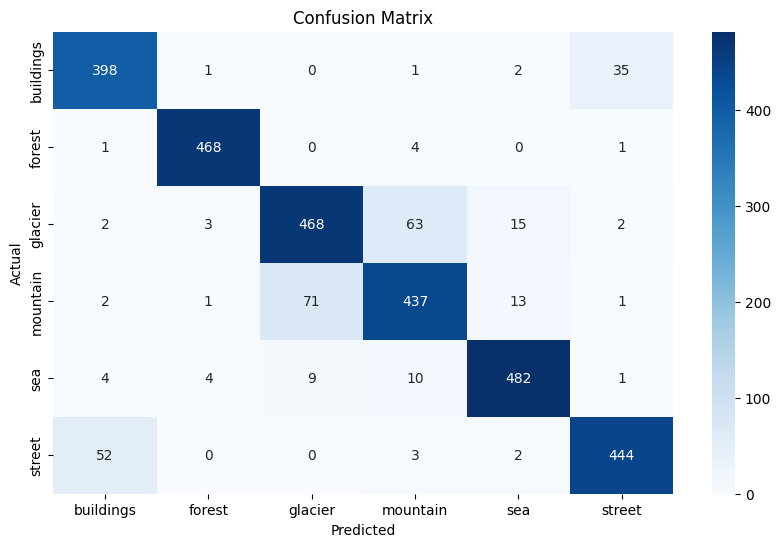

In [ ]:
# ============================================================
# CELL 10 — EVALUATE TRANSFER LEARNING
# ============================================================

tl_accuracy = evaluate_model(model_tl)

### CELL 12: Evaluate Transfer Learning Model

This cell calls the `evaluate_model` function to assess the performance of the `model_tl` (Transfer Learning model) on the `test_loader` data. The results, including accuracy, classification report, and a confusion matrix, will be printed and displayed.

# **Fine Tuning Model**

### CELL 13: Load ResNet-18 for Fine-Tuning

This cell initializes another pre-trained ResNet-18 model, but this time for the **Fine-Tuning** approach. In fine-tuning, some of the earlier layers of the pre-trained model are typically kept frozen, while later layers and the new classification head are unfrozen and trained, often with a very small learning rate.

**Special Aspects:**
-   `model_ft = models.resnet18(weights='DEFAULT')`: Loads a fresh ResNet-18 model with pre-trained weights, separate from the transfer learning model.
-   **Initial Freezing**: `for param in model_ft.parameters(): param.requires_grad = False` initially freezes *all* layers, similar to transfer learning.
-   **Selective Unfreezing**: This is the key difference for fine-tuning.
    -   `for param in model_ft.layer4.parameters(): param.requires_grad = True`
    -   `for param in model_ft.layer3.parameters(): param.requires_grad = True`
    These lines unfreeze the parameters of `layer3` and `layer4` (which are later convolutional blocks in ResNet). This allows these layers to adapt their learned features more specifically to the new dataset, rather than being fixed feature extractors.
-   **Replacing the Final Layer**: Similar to transfer learning, the final `fc` layer is replaced with a new `nn.Sequential` block tailored for the 6 output classes, including a `Dropout` layer for regularization. This new layer's parameters are, by default, trainable.
-   `model_ft = model_ft.to(device)`: Moves the model to the selected computing device.

In [ ]:
# ============================================================
# CELL 11 — LOAD RESNET18 FOR FINE TUNING
# ============================================================

model_ft = models.resnet18(weights='DEFAULT')

# Freeze all layers first
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze last layers
for param in model_ft.layer4.parameters():
    param.requires_grad = True

for param in model_ft.layer3.parameters():
    param.requires_grad = True

# Replace FC layer
num_features = model_ft.fc.in_features

model_ft.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, len(class_names))
)

model_ft = model_ft.to(device)

### CELL 14: Optimizer for Fine-Tuning

This cell defines the optimizer and learning rate scheduler specifically for the Fine-Tuning model (`model_ft`).

**Special Aspects:**
-   `optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=0.0001)`:
    -   The key difference here is `filter(lambda p: p.requires_grad, model_ft.parameters())`. This ensures that the optimizer updates **only the parameters that have `requires_grad=True`** (i.e., the unfrozen `layer3`, `layer4`, and the new `fc` layer).
    -   `lr=0.0001`: A significantly **smaller learning rate** is chosen for fine-tuning compared to transfer learning. This is because the pre-trained layers already contain valuable features, and large updates could disrupt them. Smaller learning rates allow for careful adjustments.
-   `scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=10)`: A `CosineAnnealingLR` scheduler is also used for fine-tuning, with the same `T_max` of 10 epochs. This helps in smoothly adjusting the learning rate during the fine-tuning process.

In [ ]:
# ============================================================
# CELL 12 — OPTIMIZER FOR FINE TUNING
# ============================================================

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=0.0001
)

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=10)

### CELL 15: Train Fine-Tuning Model

This cell initiates the training process for the `model_ft` (Fine-Tuning model) using the `train_model` function. Similar to the transfer learning training, it measures the time taken and stores the training and validation histories.

In [ ]:
# ============================================================
# CELL 13 — TRAIN FINE-TUNING MODEL
# ============================================================

start = time.time()

model_ft, ft_acc, ft_loss, ft_val_acc, ft_val_loss = train_model(
    model_ft,
    optimizer_ft,
    scheduler_ft,
    epochs=10
)

end = time.time()

print("Training Time:", end - start)


Epoch 1/10
------------------------------
Train Loss: 0.3637  |  Train Acc: 0.8711
Val   Loss: 0.2282  |  Val   Acc: 0.9212

Epoch 2/10
------------------------------
Train Loss: 0.2092  |  Train Acc: 0.9248
Val   Loss: 0.2122  |  Val   Acc: 0.9230

Epoch 3/10
------------------------------
Train Loss: 0.1719  |  Train Acc: 0.9409
Val   Loss: 0.1939  |  Val   Acc: 0.9277

Epoch 4/10
------------------------------
Train Loss: 0.1345  |  Train Acc: 0.9521
Val   Loss: 0.2007  |  Val   Acc: 0.9266

Epoch 5/10
------------------------------
Train Loss: 0.1070  |  Train Acc: 0.9623
Val   Loss: 0.2167  |  Val   Acc: 0.9305

Epoch 6/10
------------------------------
Train Loss: 0.0846  |  Train Acc: 0.9704
Val   Loss: 0.2126  |  Val   Acc: 0.9316

Epoch 7/10
------------------------------
Train Loss: 0.0650  |  Train Acc: 0.9791
Val   Loss: 0.2245  |  Val   Acc: 0.9266

Epoch 8/10
------------------------------
Train Loss: 0.0562  |  Train Acc: 0.9811
Val   Loss: 0.2206  |  Val   Acc: 0.9330


### CELL 16: Evaluate Fine-Tuning Model

This cell calls the `evaluate_model` function to assess the performance of the `model_ft` (Fine-Tuning model) on the `test_loader` data. The accuracy, classification report, and a confusion matrix will be displayed, allowing for a comparison with the transfer learning results.


Accuracy: 0.9363333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       437
           1       0.99      0.99      0.99       474
           2       0.92      0.88      0.90       553
           3       0.91      0.90      0.90       525
           4       0.94      0.99      0.96       510
           5       0.95      0.93      0.94       501

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



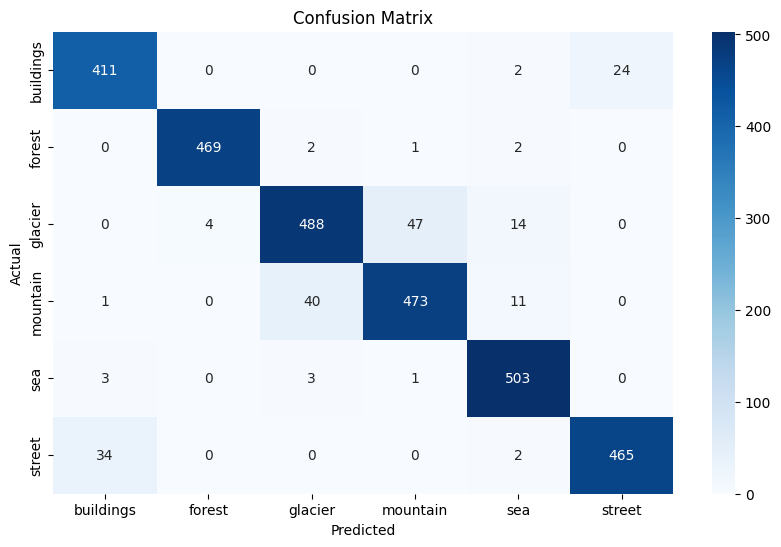

In [ ]:
# ============================================================
# CELL 14 — EVALUATE FINE-TUNING MODEL
# ============================================================

ft_accuracy = evaluate_model(model_ft)

### CELL 17: Plot Accuracy Comparison

This cell generates a bar chart to visually compare the final test accuracies achieved by the Transfer Learning and Fine-Tuning models.

**Special Aspects:**
-   `models_names = ["Transfer Learning", "Fine-Tuning"]` and `accuracies = [tl_accuracy, ft_accuracy]`: Defines the labels and data for the bar chart.
-   `plt.bar(models_names, accuracies)`: Creates the bar chart.
-   **Displaying Values on Bars**: The loop iterates through the bars and uses `plt.text()` to display the exact accuracy value on top of each bar, rounded to 4 decimal places. This makes the comparison more precise and readable.

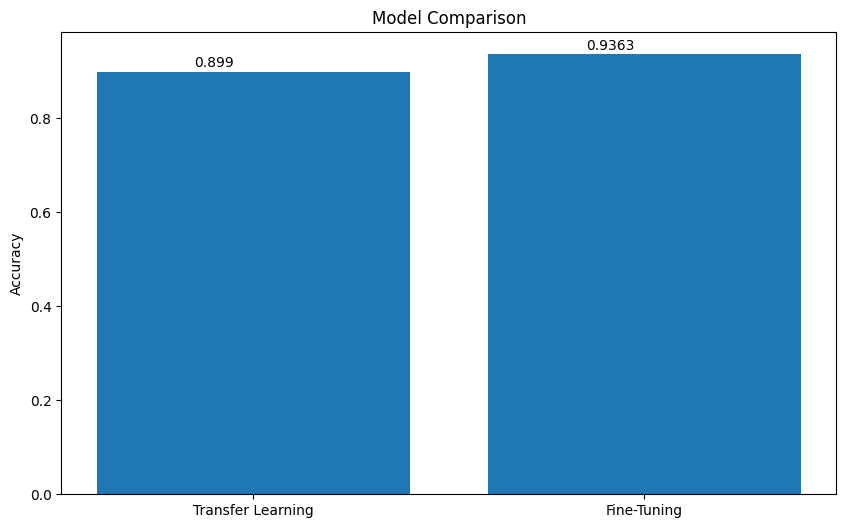

In [ ]:
# ============================================================
# CELL 15 — PLOT ACCURACY COMPARISON
# ============================================================

models_names = ["Transfer Learning", "Fine-Tuning"]
accuracies = [tl_accuracy, ft_accuracy]

plt.figure(figsize=(10,6))

bars = plt.bar(models_names, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + 0.25,
        yval + 0.01,
        round(yval, 4)
    )

plt.show()

### CELL 18: Plot Training History Comparison

This cell generates a set of four plots to visualize the training and validation accuracy and loss over epochs for both the Transfer Learning and Fine-Tuning models. This allows for a detailed comparison of how each model learned and performed during training.

**Special Aspects:**
-   `plt.figure(figsize=(16, 10))`: Sets up a larger figure to accommodate four subplots.
-   `plt.subplot(2, 2, 1)`, `plt.subplot(2, 2, 2)`, etc.: Creates a 2x2 grid of subplots and specifies which subplot to draw on next.
-   **Accuracy Plots**: Two subplots show the training and validation accuracy for Transfer Learning and Fine-Tuning, respectively. The `linestyle="--"` is used for training accuracy to differentiate it from validation accuracy.
-   **Loss Plots**: Similarly, two subplots show the training and validation loss for both models.
-   `plt.legend()`: Displays the legend to identify which line corresponds to training vs. validation.
-   `plt.tight_layout()`: Automatically adjusts subplot parameters for a tight layout, preventing labels and titles from overlapping.

By comparing these plots, one can observe learning curves, identify signs of overfitting/underfitting, and understand the stability of training for both approaches.

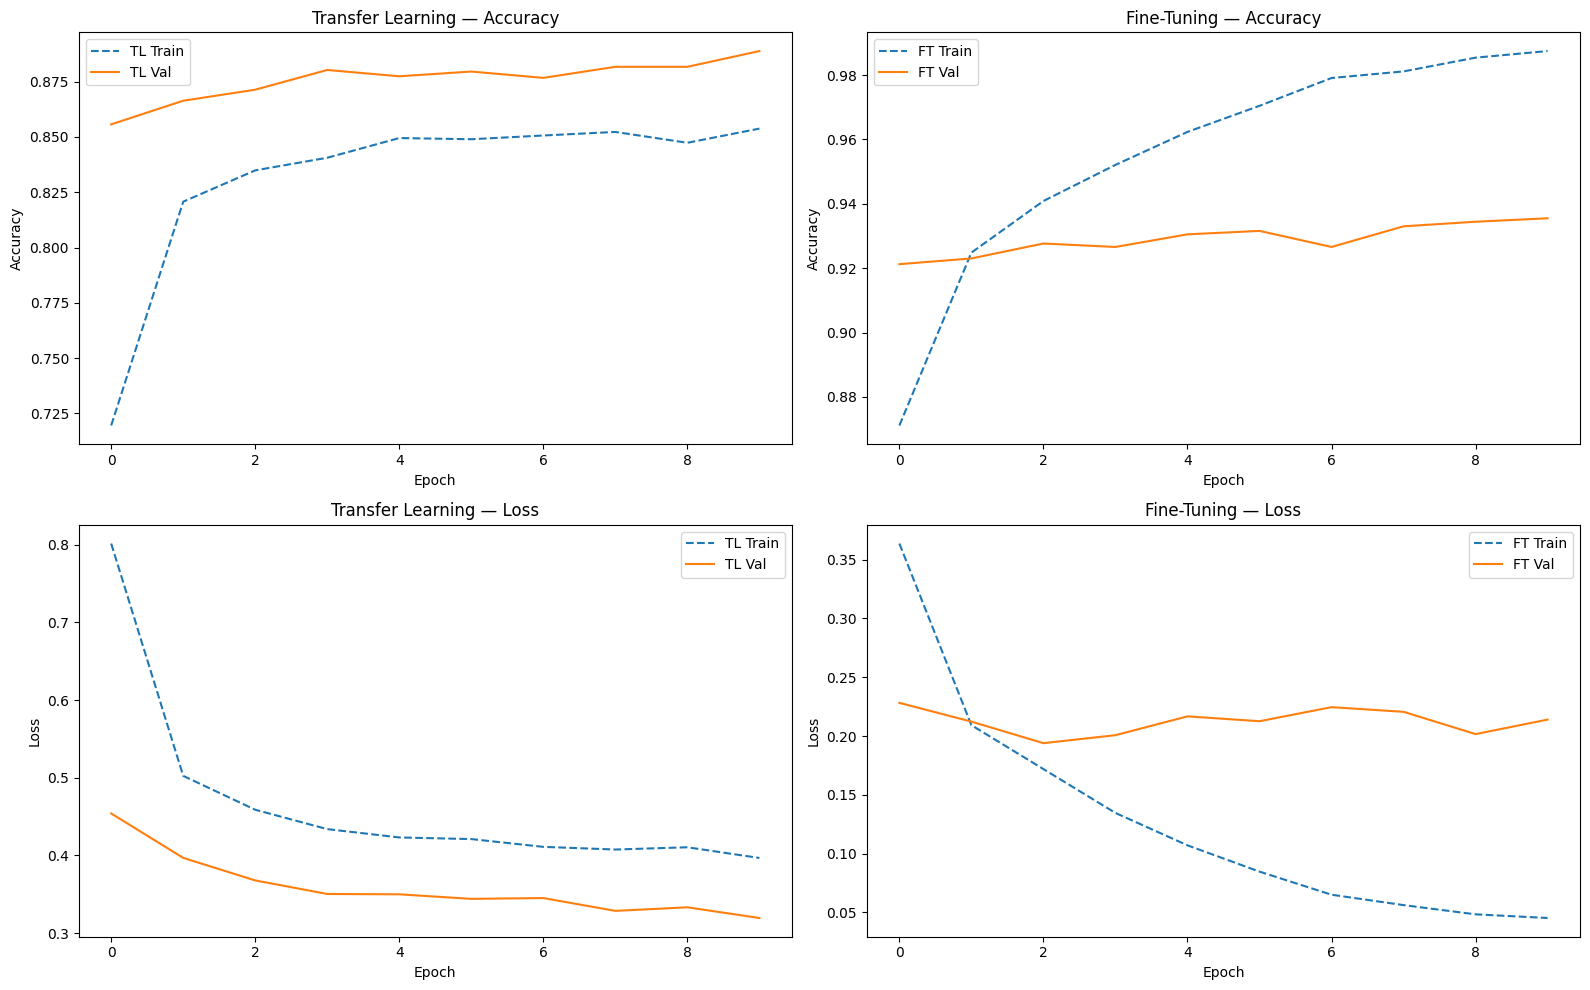

In [ ]:
plt.figure(figsize=(16, 10))

# ── Accuracy ──
plt.subplot(2, 2, 1)
plt.plot(tl_acc, label="TL Train", linestyle="--")
plt.plot(tl_val_acc, label="TL Val")
plt.title("Transfer Learning — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(ft_acc, label="FT Train", linestyle="--")
plt.plot(ft_val_acc, label="FT Val")
plt.title("Fine-Tuning — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ── Loss ──
plt.subplot(2, 2, 3)
plt.plot(tl_loss, label="TL Train", linestyle="--")
plt.plot(tl_val_loss, label="TL Val")
plt.title("Transfer Learning — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(ft_loss, label="FT Train", linestyle="--")
plt.plot(ft_val_loss, label="FT Val")
plt.title("Fine-Tuning — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### CELL 19: Save Models

This cell saves the trained models' state dictionaries to disk. Saving the state dictionary (`state_dict()`) is a common practice in PyTorch to save only the learned parameters (weights and biases) of the model, which makes the file size smaller and allows for flexible loading into potentially different model architectures (as long as the layers match).

**Special Aspects:**
-   `torch.save(model_tl.state_dict(), "transfer_learning_resnet18.pth")`:
    -   `model_tl.state_dict()`: Returns a Python dictionary containing all the learned parameters of the `model_tl`.
    -   `"transfer_learning_resnet18.pth"`: Specifies the filename for the saved state dictionary. The `.pth` or `.pt` extension is commonly used for PyTorch model files.
-   The same process is repeated for `model_ft`, saving its state dictionary to `"fine_tuning_resnet18.pth"`.

This allows the trained models to be reloaded later without needing to retrain them, which is essential for deployment or further experimentation.

In [ ]:
# ============================================================
# CELL 17 — SAVE MODELS
# ============================================================

torch.save(model_tl.state_dict(), "transfer_learning_resnet18.pth")

torch.save(model_ft.state_dict(), "fine_tuning_resnet18.pth")

print("Models Saved Successfully")

Models Saved Successfully


In [ ]:
import gradio as gr
import torch
import numpy as np

# 1. Custom Theme & CSS for a "Technical Terminal" look
theme = gr.themes.Monochrome(
    primary_hue="green",
    radius_size="none", # Sharp edges for a professional look
).set(
    block_background_fill="#121212",
    block_border_width="1px",
    button_primary_background_fill="#00ff41", # Matrix Green
    button_primary_text_color="black",
)

def workbench_predict(image, model_choice):
    if image is None: return "No Image Provided", None

    # Preprocessing
    img_tensor = preprocess(image).unsqueeze(0).to(device)

    # Select Model based on Sidebar Toggle
    selected_model = model_tl if model_choice == "Transfer Learning" else model_ft
    selected_model.eval()

    with torch.no_grad():
        outputs = selected_model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

        # Format results for the Label and a Technical JSON box
        confidences = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}
        top_pred = class_names[torch.argmax(probabilities).item()]

    return confidences, f"Model: {model_choice} | Result: {top_pred.upper()}"

# 2. Build the Workbench
with gr.Blocks() as demo:
    gr.HTML("<h1 style='color: #00ff41; font-family: monospace;'>[ VISION_SYSTEM_v2.0 ]</h1>")

    with gr.Row():
        # --- LEFT SIDEBAR (Control Panel) ---
        with gr.Column(scale=1, variant="panel"):
            gr.Markdown("### ⚙️ SYSTEM SETTINGS")
            model_toggle = gr.Radio(
                choices=["Transfer Learning", "Fine-Tuning"],
                value="Transfer Learning",
                label="Active Neural Network"
            )
            gr.Markdown("---")
            gr.Markdown("**Device Status:** `GPU_ACCELERATED`" if torch.cuda.is_available() else "**Device Status:** `CPU_ONLY`_")
            gr.Markdown("**Architecture:** `ResNet-18`")
            run_btn = gr.Button("START INFERENCE", variant="primary")
            clear_btn = gr.Button("RESET SYSTEM")

        # --- RIGHT MAIN SECTION (Input/Output) ---
        with gr.Tabs():
            with gr.TabItem("📁 File Upload"):
                image_input = gr.Image(type="pil", label="Drop Satellite or Landscape Data")

            with gr.TabItem("📷 Live Webcam"):
                webcam_input = gr.Image(sources=["webcam"], type="pil", label="Hardware Capture")

        with gr.Row():
            with gr.Column():
                gr.Markdown("### 🔍 Classification Probabilities")
                label_output = gr.Label(num_top_classes=4)
            with gr.Column():
                gr.Markdown("### 📟 System Logs")
                status_output = gr.Textbox(label="Status Trace", placeholder="Waiting for input...", interactive=False)

    # 3. Logic - Both inputs trigger the same function
    # We use a helper to determine which image to use
    def handle_inference(file_img, web_img, model_opt):
        img = file_img if file_img is not None else web_img
        return workbench_predict(img, model_opt)

    run_btn.click(
        fn=handle_inference,
        inputs=[image_input, webcam_input, model_toggle],
        outputs=[label_output, status_output]
    )

    clear_btn.click(lambda: [None, None, None, "System Reset"], outputs=[image_input, webcam_input, label_output, status_output])

demo.launch(share=True, theme=theme)

/tmp/ipykernel_2279/591207059.py:37: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d80fdbe7fae6f27820.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
